# SMT vs DeepAR on `electricity`

**Supervised Memory Training (SMT)** ([Kumar & Isola, 2026](https://arxiv.org/abs/2606.06479)) trains a
recurrent forecaster *without* backpropagation through time. A Transformer **encoder** summarizes the
past (target lags + covariates) into a memory state `m`; a **masked (causal) decoder** predicts each
future target from the previous future target + future covariates (teacher forcing), giving the
predictive-state objective. A small recurrent **memory cell** is trained by regressing onto the
teacher's one-step memory transitions `(m_t, x_{t+1}) -> m_{t+1}` (a one-step MSE, no BPTT), plus a
uniformity regularizer.

At inference the encoder seeds the memory and the **recurrent cell is unrolled with O(1) state**,
sampling autoregressively — so the deployed model is a genuine RNN trained without BPTT (the decoder
is only used during training).

Everything else mirrors `DeepAR`: lags, time/age features, static embeddings, mean scaling and a
`DistributionOutput` head. Here we compare the two on the GluonTS `electricity` benchmark.

In [1]:
# Use this repo's gluonts (the SMT model lives on the `smt-model` branch) rather than any
# installed wheel, and relax torch>=2.6's weights_only default so checkpoints reload.
import sys, os, functools, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import torch
torch.serialization.add_safe_globals([functools.partial])
_orig_load = torch.load
torch.load = lambda *a, **k: _orig_load(*a, **{**k, 'weights_only': False})


In [2]:
from itertools import islice
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from gluonts.dataset.repository import get_dataset
from gluonts.evaluation import make_evaluation_predictions, Evaluator
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.model.smt import SMTEstimator


In [3]:
dataset = get_dataset('electricity')
prediction_length = dataset.metadata.prediction_length
freq = dataset.metadata.freq
context_length = 168  # one week of hourly history
prediction_length, freq


(24, '1H')

In [15]:
common = dict(
    freq=freq,
    prediction_length=prediction_length,
    context_length=context_length,
    batch_size=64,
    num_batches_per_epoch=100,
    num_parallel_samples=100,
    trainer_kwargs=dict(accelerator='auto', max_epochs=30),
)


## DeepAR


In [16]:
deepar_estimator = DeepAREstimator(num_layers=2, hidden_size=40, **common)
deepar_predictor = deepar_estimator.train(dataset.train, cache_data=True, shuffle_buffer_length=1024)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 27.6 K | train | [[1, 1], [1, 1], [1, 888, 5], [1, 888], [1, 888], [1, 24, 5]] | [1, 100, 24]
-----------------------------------------------------------------------------------------------------------------------------
27.6 K    Trainable params
0         Non-trainable params
27.6 K    Total params
0.111     Total estimated model params size (MB)


Training: |                                                                                                   …

Epoch 0, global step 100: 'train_loss' reached 6.26997 (best 6.26997), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_755/checkpoints/epoch=0-step=100.ckpt' as top 1
Epoch 1, global step 200: 'train_loss' reached 5.64397 (best 5.64397), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_755/checkpoints/epoch=1-step=200.ckpt' as top 1
Epoch 2, global step 300: 'train_loss' reached 5.51361 (best 5.51361), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_755/checkpoints/epoch=2-step=300.ckpt' as top 1
Epoch 3, global step 400: 'train_loss' reached 5.44793 (best 5.44793), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_755/checkpoints/epoch=3-step=400.ckpt' as top 1
Epoch 4, global step 500: 'train_loss' reached 5.41353 (best 5.41353), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_755/checkpoints/epoch=4-step=500.ckpt' as top 1
Epoch 5, g

In [17]:
fc_it, ts_it = make_evaluation_predictions(dataset=dataset.test, predictor=deepar_predictor, num_samples=100)
deepar_forecasts, tss = list(fc_it), list(ts_it)
deepar_agg, _ = Evaluator()(iter(tss), iter(deepar_forecasts))
deepar_agg['MASE'], deepar_agg['mean_wQuantileLoss']

Running evaluation: 2247it [00:00, 8470.87it/s]
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Git

(2.258120600814941, 0.18602578801749545)

## SMT

Sized to ~30K trainable params to roughly match DeepAR's 27.6K (`d_model=24`, 2 encoder /
1 decoder / 1 memory-cell layers). The uniformity loss is `pdist`-free so training runs on
MPS/CUDA/CPU alike.


In [18]:
# sized to ~30K params to roughly match DeepAR's 27.6K for a fair comparison
smt_estimator = SMTEstimator(
    d_model=24, nhead=4,
    num_encoder_layers=2, num_decoder_layers=1, num_rnn_layers=1,
    mem_tokens=4, coef_dyn=1.0, coef_unif=0.01,
    **common,
)
smt_predictor = smt_estimator.train(dataset.train, cache_data=True, shuffle_buffer_length=1024)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type     | Params | Mode  | In sizes                                                      | Out sizes   
--------------------------------------------------------------------------------------------------------------------------
0 | model | SMTModel | 30.3 K | train | [[1, 1], [1, 1], [1, 888, 5], [1, 888], [1, 888], [1, 24, 5]] | [1, 100, 24]
--------------------------------------------------------------------------------------------------------------------------
30.3 K    Trainable params
0         Non-trainable params
30.3 K    Total params
0.121     Total estimated model params size (MB)


Training: |                                                                                                   …

Epoch 0, global step 100: 'train_loss' reached 6.20690 (best 6.20690), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_756/checkpoints/epoch=0-step=100.ckpt' as top 1
Epoch 1, global step 200: 'train_loss' reached 5.69673 (best 5.69673), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_756/checkpoints/epoch=1-step=200.ckpt' as top 1
Epoch 2, global step 300: 'train_loss' reached 5.43825 (best 5.43825), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_756/checkpoints/epoch=2-step=300.ckpt' as top 1
Epoch 3, global step 400: 'train_loss' was not in top 1
Epoch 4, global step 500: 'train_loss' was not in top 1
Epoch 5, global step 600: 'train_loss' reached 5.42454 (best 5.42454), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_756/checkpoints/epoch=5-step=600.ckpt' as top 1
Epoch 6, global step 700: 'train_loss' reached 5.29947 (best 5.29947), saving model to '/Users/k

In [19]:
fc_it, ts_it = make_evaluation_predictions(dataset=dataset.test, predictor=smt_predictor, num_samples=100)
smt_forecasts, tss = list(fc_it), list(ts_it)
smt_agg, _ = Evaluator()(iter(tss), iter(smt_forecasts))
smt_agg['MASE'], smt_agg['mean_wQuantileLoss']

Running evaluation: 2247it [00:00, 8506.66it/s]
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Git

(0.7764089804231313, 0.08212293742991814)

## SMT → DMT (DAgger Memory Training)

The single-step SMT dynamics loss only ever feeds the recurrent cell the teacher's
*oracle* memory, so it never sees the drift that builds up when the cell is rolled out
on its **own** states at deployment. DMT (Kumar & Isola, 2026, Sec. 2.3) is a short
finetuning phase that fixes this on-policy: the cell is unrolled with its own memory and
regressed onto the teacher encoder's sliding-window memory trajectory (the context window
walks one step at a time out of the past and into the future window). The teacher
(encoder/decoder) is frozen and only the recurrent cell is trained, at a small learning
rate. Enable it with a single flag, `dmt_finetune_epochs > 0` — the full `SMT → DMT` method.

In [20]:
# Same architecture as SMT above, plus a DMT finetuning phase. dmt_rollout_steps
# defaults to prediction_length (the deployment horizon we want to de-drift).
smt_dmt_estimator = SMTEstimator(
    d_model=24, nhead=4,
    num_encoder_layers=2, num_decoder_layers=1, num_rnn_layers=1,
    mem_tokens=4, coef_dyn=1.0, coef_unif=0.01,
    dmt_finetune_epochs=5, dmt_lr=1e-4,
    **common,
)
smt_dmt_predictor = smt_dmt_estimator.train(dataset.train, cache_data=True, shuffle_buffer_length=1024)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type     | Params | Mode  | In sizes                                                      | Out sizes   
--------------------------------------------------------------------------------------------------------------------------
0 | model | SMTModel | 30.3 K | train | [[1, 1], [1, 1], [1, 888, 5], [1, 888], [1, 888], [1, 24, 5]] | [1, 100, 24]
--------------------------------------------------------------------------------------------------------------------------
30.3 K    Trainable params
0         Non-trainable params
30.3 K    Total params
0.121     Total estimated model params size (MB)


Training: |                                                                                                   …

Epoch 0, global step 100: 'train_loss' reached 6.36847 (best 6.36847), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_757/checkpoints/epoch=0-step=100.ckpt' as top 1
Epoch 1, global step 200: 'train_loss' reached 5.73820 (best 5.73820), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_757/checkpoints/epoch=1-step=200.ckpt' as top 1
Epoch 2, global step 300: 'train_loss' reached 5.55404 (best 5.55404), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_757/checkpoints/epoch=2-step=300.ckpt' as top 1
Epoch 3, global step 400: 'train_loss' reached 5.50220 (best 5.50220), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_757/checkpoints/epoch=3-step=400.ckpt' as top 1
Epoch 4, global step 500: 'train_loss' reached 5.40726 (best 5.40726), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_757/checkpoints/epoch=4-step=500.ckpt' as top 1
Epoch 5, g

Training: |                                                                                                   …

Epoch 0, global step 100: 'train_loss' reached 0.05814 (best 0.05814), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_758/checkpoints/epoch=0-step=100.ckpt' as top 1
Epoch 1, global step 200: 'train_loss' reached 0.05249 (best 0.05249), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_758/checkpoints/epoch=1-step=200.ckpt' as top 1
Epoch 2, global step 300: 'train_loss' reached 0.04929 (best 0.04929), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_758/checkpoints/epoch=2-step=300.ckpt' as top 1
Epoch 3, global step 400: 'train_loss' reached 0.04804 (best 0.04804), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_758/checkpoints/epoch=3-step=400.ckpt' as top 1
Epoch 4, global step 500: 'train_loss' reached 0.04652 (best 0.04652), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_758/checkpoints/epoch=4-step=500.ckpt' as top 1
`Trainer.f

In [21]:
fc_it, ts_it = make_evaluation_predictions(dataset=dataset.test, predictor=smt_dmt_predictor, num_samples=100)
smt_dmt_forecasts = list(fc_it)
smt_dmt_agg, _ = Evaluator()(iter(list(ts_it)), iter(smt_dmt_forecasts))
smt_dmt_agg['MASE'], smt_dmt_agg['mean_wQuantileLoss']

Running evaluation: 2247it [00:00, 9324.77it/s]
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Github/gluon-ts/src/gluonts/evaluation/_base.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  metrics["ND"] = cast(float, metrics["abs_error"]) / cast(
/Users/kashif/Git

(0.7575670981844145, 0.07051028444861081)

## Comparison


In [22]:
metrics = ['MASE', 'sMAPE', 'wQuantileLoss[0.5]', 'mean_wQuantileLoss', 'RMSE']
pd.DataFrame({
    'DeepAR':   {m: deepar_agg[m]   for m in metrics},
    'SMT':      {m: smt_agg[m]      for m in metrics},
    'SMT→DMT':  {m: smt_dmt_agg[m]  for m in metrics},
}).round(4)

,DeepAR,SMT,SMT→DMT
MASE,2.2581,0.7764,0.7576
sMAPE,0.2305,0.1095,0.1077
wQuantileLoss[0.5],0.2289,0.0979,0.0859
mean_wQuantileLoss,0.1860,0.0821,0.0705
RMSE,5014.0109,2782.5711,2108.1053


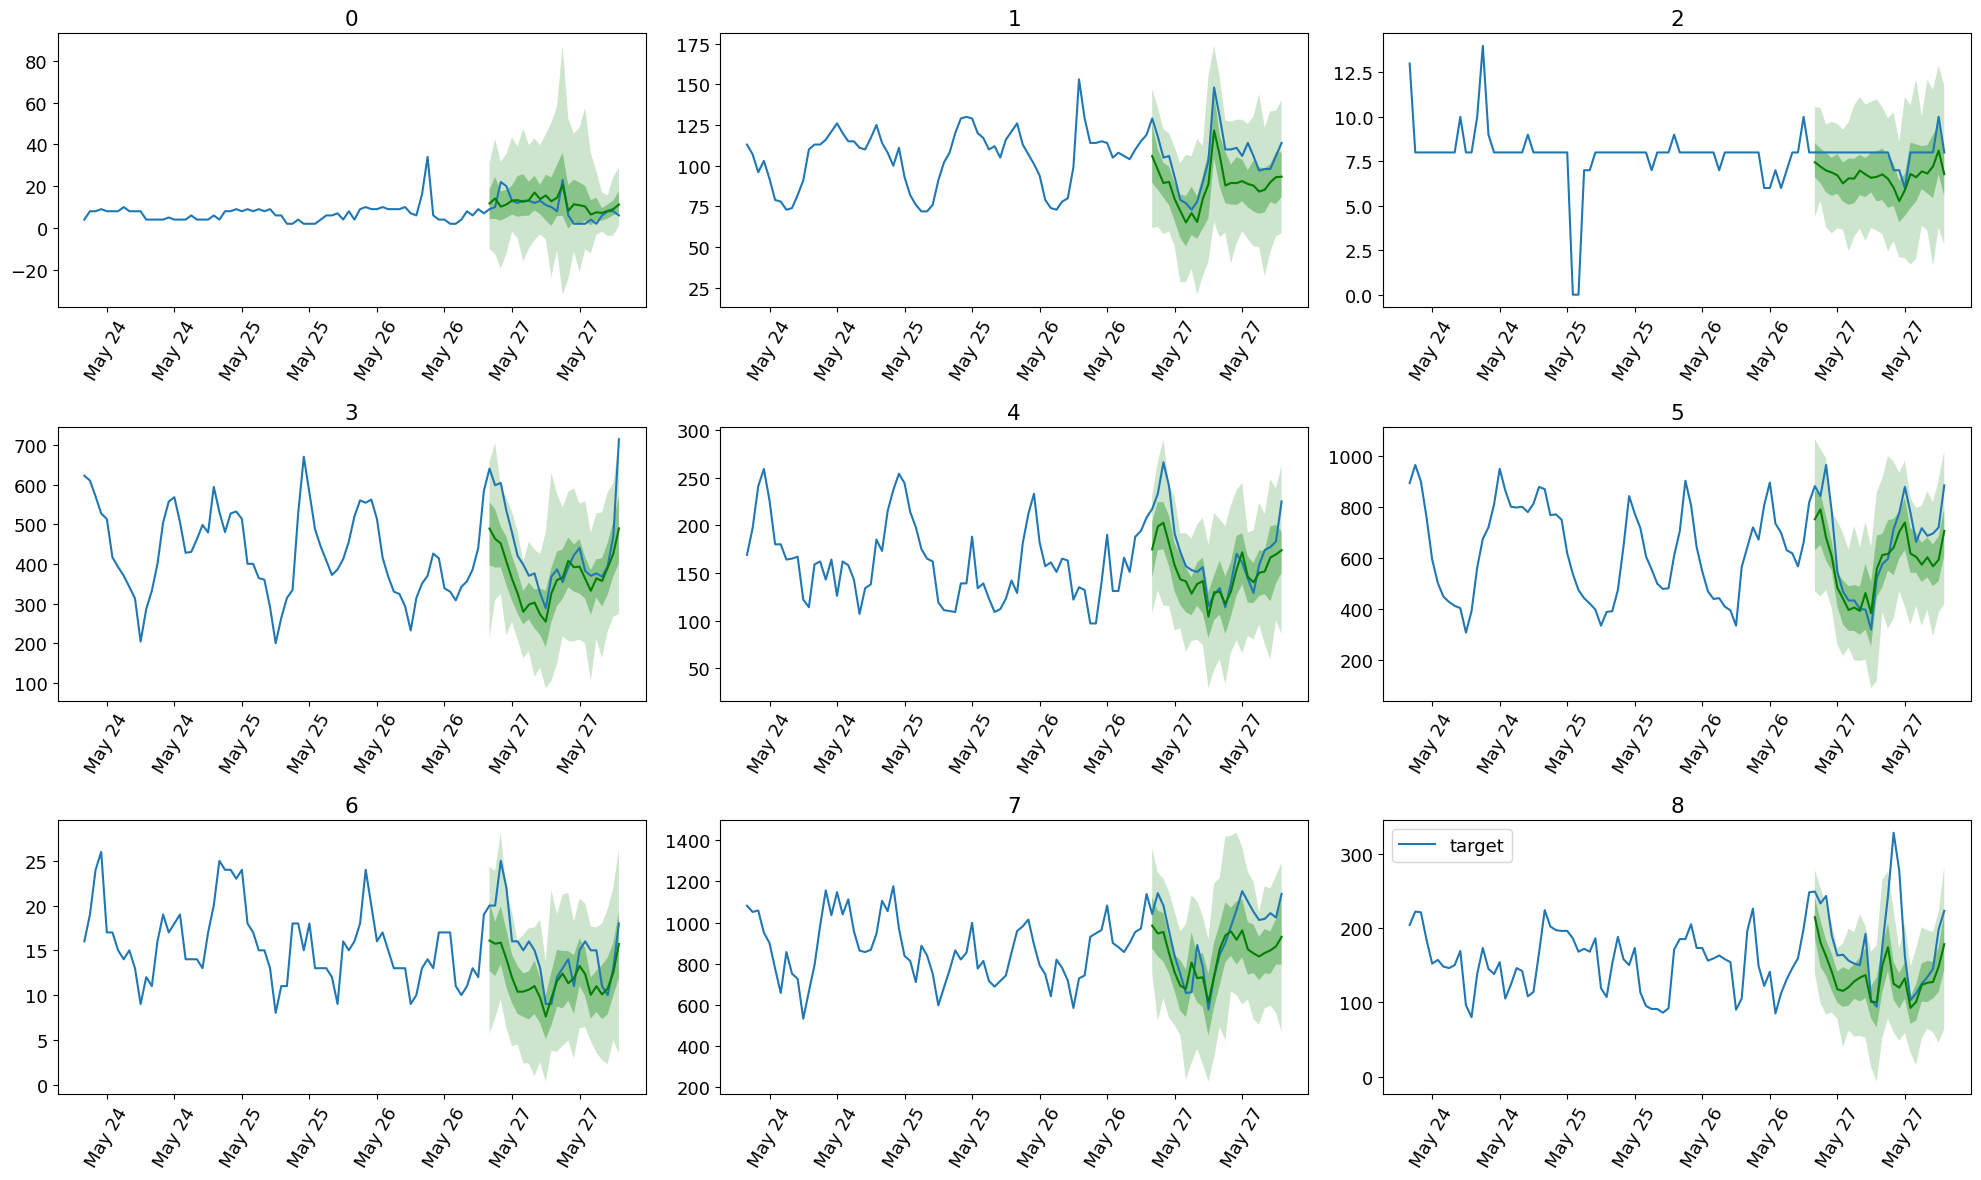

In [23]:
# Sample forecasts from the DeepAR model
plt.figure(figsize=(20, 12))
date_formater = mdates.DateFormatter('%b %d')
plt.rcParams.update({'font.size': 13})
for idx, (forecast, ts) in islice(enumerate(zip(deepar_forecasts, tss)), 9):
    ax = plt.subplot(3, 3, idx + 1)
    plt.plot(ts[-4 * prediction_length:].to_timestamp(), label='target')
    forecast.plot(color='g')
    plt.xticks(rotation=60)
    ax.xaxis.set_major_formatter(date_formater)
    ax.set_title(forecast.item_id)
plt.gcf().tight_layout(); plt.legend(); plt.show()


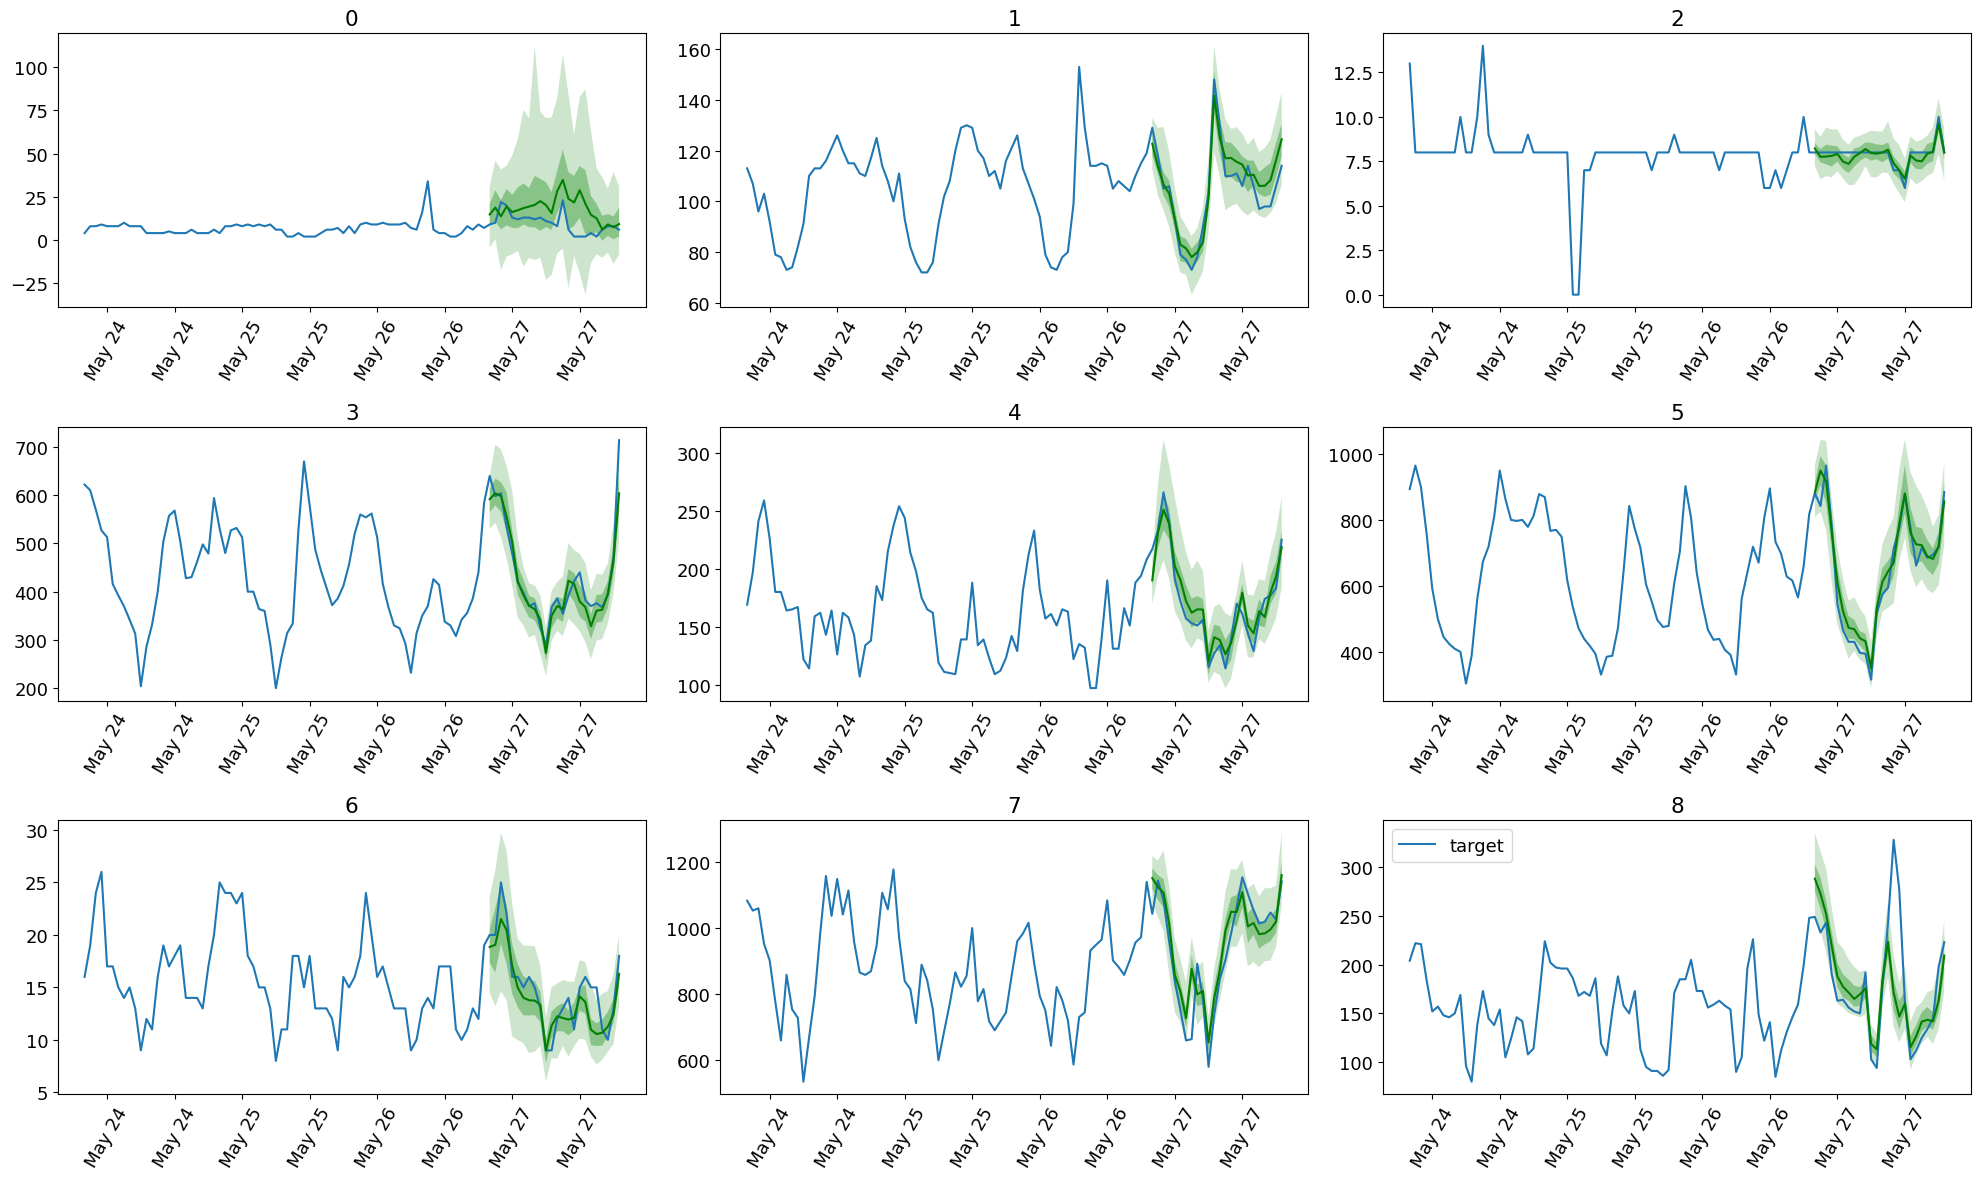

In [24]:
# Sample forecasts from the SMT model
plt.figure(figsize=(20, 12))
date_formater = mdates.DateFormatter('%b %d')
plt.rcParams.update({'font.size': 13})
for idx, (forecast, ts) in islice(enumerate(zip(smt_forecasts, tss)), 9):
    ax = plt.subplot(3, 3, idx + 1)
    plt.plot(ts[-4 * prediction_length:].to_timestamp(), label='target')
    forecast.plot(color='g')
    plt.xticks(rotation=60)
    ax.xaxis.set_major_formatter(date_formater)
    ax.set_title(forecast.item_id)
plt.gcf().tight_layout(); plt.legend(); plt.show()


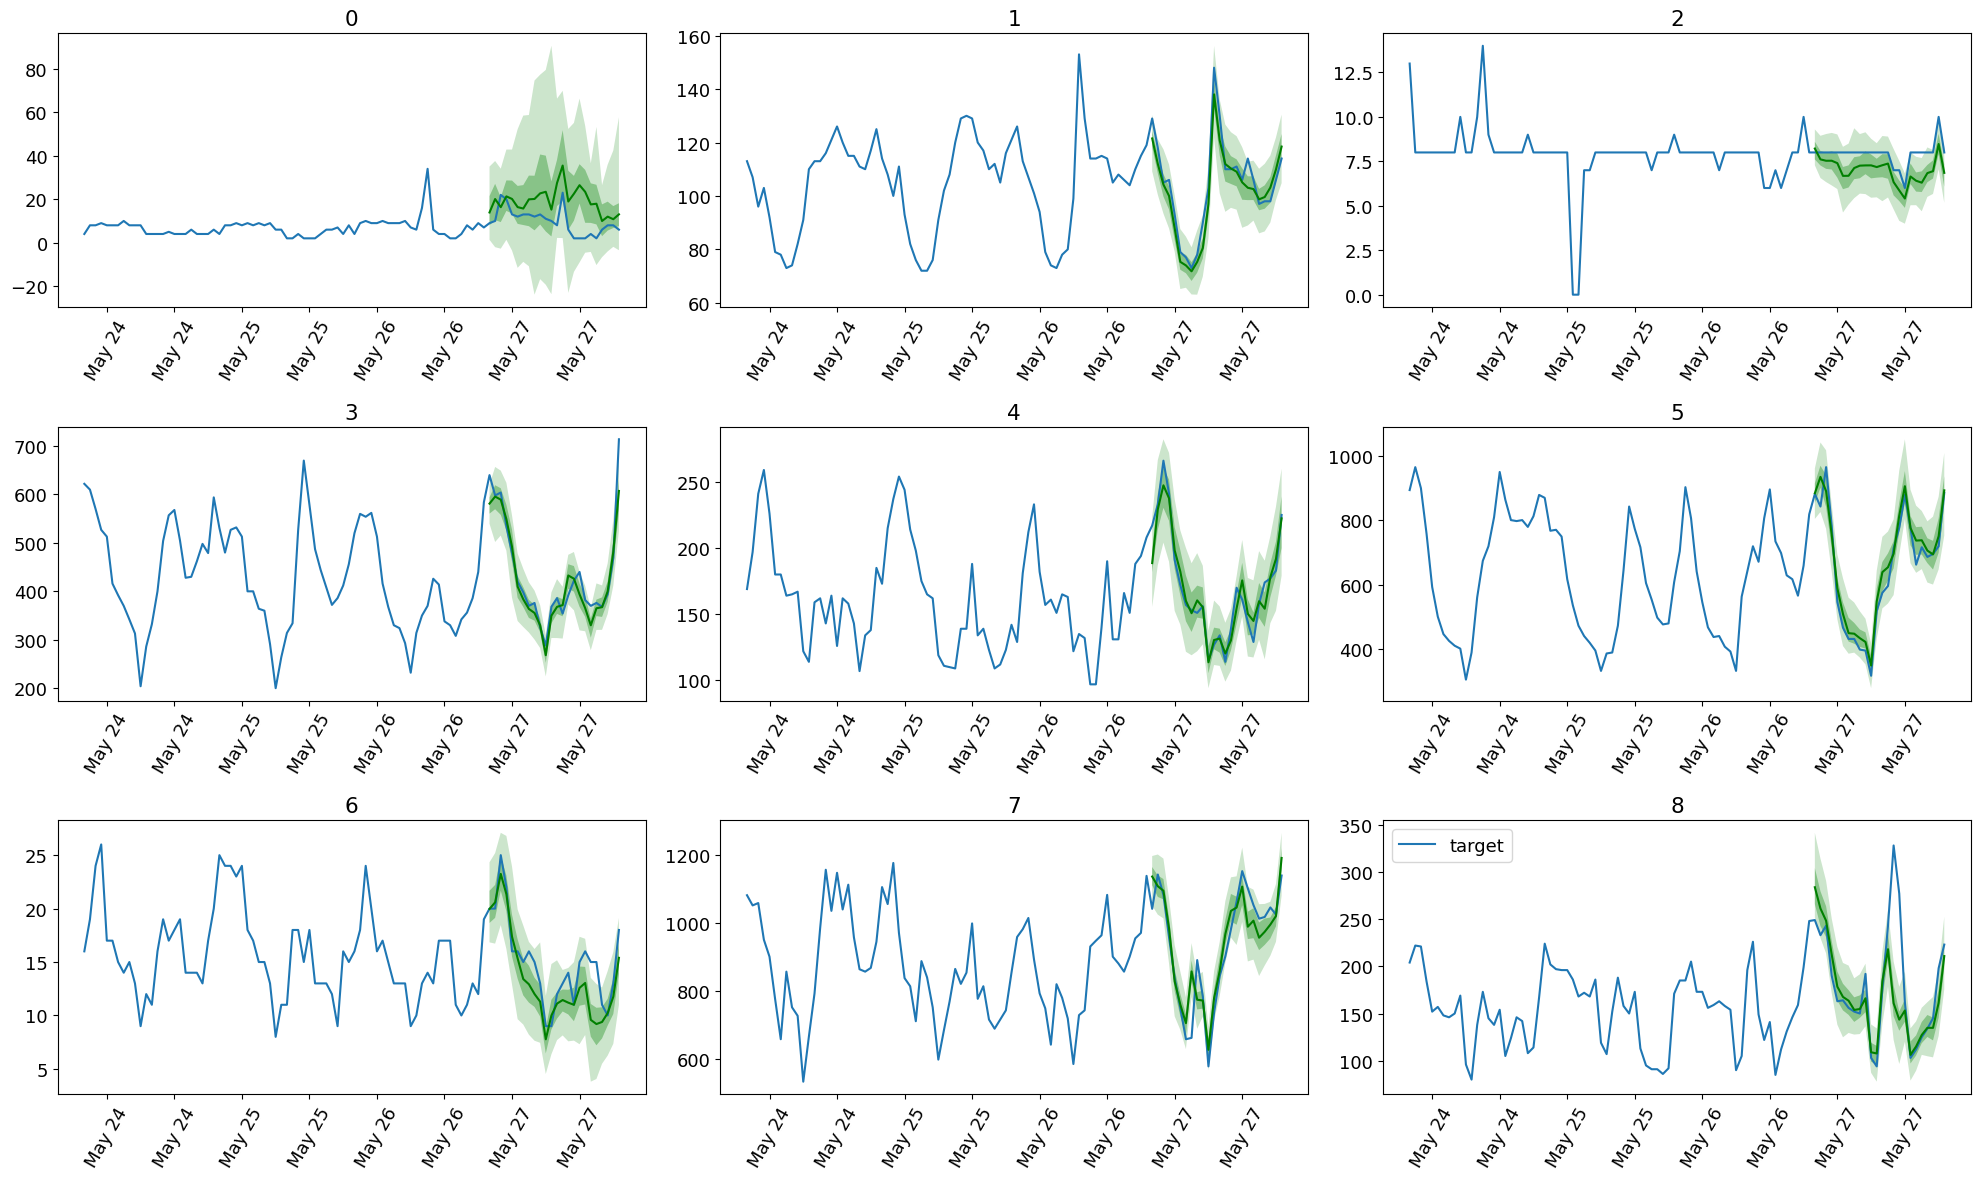

In [25]:
# Sample forecasts from the SMT + DMT model
plt.figure(figsize=(20, 12))
date_formater = mdates.DateFormatter('%b %d')
plt.rcParams.update({'font.size': 13})
for idx, (forecast, ts) in islice(enumerate(zip(smt_dmt_forecasts, tss)), 9):
    ax = plt.subplot(3, 3, idx + 1)
    plt.plot(ts[-4 * prediction_length:].to_timestamp(), label='target')
    forecast.plot(color='g')
    plt.xticks(rotation=60)
    ax.xaxis.set_major_formatter(date_formater)
    ax.set_title(forecast.item_id)
plt.gcf().tight_layout(); plt.legend(); plt.show()
